# Paper-exact reproduction: multilingual circuits on Qwen3-4B

Reproduces the biology paper's Multilingual Circuits dive
([biology.html §Multilingual](https://transformer-circuits.pub/2025/attribution-graphs/biology.html#dives-multilingual))
on Qwen3-4B + `mwhanna/qwen3-4b-transcoders`. Paper values: `notes/biology_digest.md` §B;
verdicts: the Summary below and `DEVLOG.md`.

**Setup facts**
- Both prompt formats run side by side, as **fully separate selections**: the paper's
  exact **raw** open-quote completions (`The opposite of "small" is "`, one sink token
  prepended, `n_bos_tokens=1`) and our **chat** instruction adaptation (Qwen3-4B is an
  instruct model; the answer is the first generated token). Each format's jobs steer
  only supernodes selected on that format's pages. The **language swap is raw-only** —
  its quote supernodes exist only on the raw pages: chat prompts end on
  assistant-header scaffold tokens, not the content-bearing open quote.
- Steering: paper multiples are multiplicative M, ours additive `m = M − 1`
  (paper −5× ⇒ m=−6, −0.5× ⇒ m=−1.5). Donors are injected at the absolute
  `value = mult × stored act` recorded on their donor graph.

**v3 pipeline** — interventions run the paper's **constrained patching** only
(activations at layers ≤ ℓ pinned at their perturbed values, the real model after ℓ;
ℓ swept per experiment on p(expected) and stated per result). Supernodes load from the
**two reviewed artifacts** `supernodes/multilingual_{chat,raw}_4b.json`: chat and raw
selections are separate, members are ranked **earliest layer first** (both user
decisions, 2026-07-12 — early steered sets leave the ℓ sweep room), and the seeds were
materialized into the committed exports and approved as-is (`build_supernodes.py
--materialize-seeds`; the review_log records the provenance). Graphs load from the
`build_supernode_inputs.py` dumps. v1 (propagate mode) and v2 (merged chat+raw
selection, act-ranked, hand-reviewed 2026-07-11) live in git history and `DEVLOG.md`.

## What actually runs — exact model inputs, supernodes, artifacts

### The ten graphs (loaded from `artifacts/supernode_inputs/4b/`, manifest-checked)

| graph | format | prompt (chat = the user line of the templated input; raw = sink token prepended) | answer | tokens | final | operand | prune |
|---|---|---|---|---|---|---|---|
| `antonym_en` | chat | `What is the opposite of "small"? Reply with only the word, nothing else.` | 'large' | 29 | 28 | 9 | 0.8 |
| `antonym_fr` | chat | `Quel est le contraire de "petit" ? Réponds avec un seul mot, rien d'autre.` | 'Grand' | 37 | 36 | 12 | 0.8 |
| `antonym_zh` | chat | `"小"的反义词是什么？只回答一个词，不要其他内容。` | '大' | 30 | 29 | 4 | 0.8 |
| `synonym_en` | chat | `Give one synonym of "small". Reply with only the word, nothing else.` | 'tiny' | 28 | 27 | 8 | 0.8 |
| `hot_en` | chat | `What is the opposite of "hot"? Reply with only the word, nothing else.` | 'cold' | 29 | 28 | 9 | 0.8 |
| `raw_antonym_en` | raw | `The opposite of "small" is "` | 'large' | 9 | 8 | 5 | 0.95 |
| `raw_antonym_fr` | raw | `Le contraire de "petit" est "` | 'grand' | 11 | 10 | 7 | 0.95 |
| `raw_antonym_zh` | raw | `"小"的反义词是"` | '大' | 10 | 9 | 2 | 0.95 |
| `raw_synonym_en` | raw | `A synonym of "small" is "` | 'tiny' | 9 | 8 | 5 | 0.95 |
| `raw_hot_en` | raw | `The opposite of "hot" is "` | 'cold' | 9 | 8 | 5 | 0.95 |

Chat prompts go through the Qwen3 chat template with thinking disabled — the final
position is the last assistant-header scaffold token, and the answer is the first
generated token. Raw prompts are the paper's exact completions with one sink token
prepended (transcoders cannot reconstruct position 0); their final position IS the
content-bearing open quote. Chat graphs are pruned at 0.8 (circuit-tracer default),
raw at 0.95 (at 0.8 they starve — no quote-position nodes survive for the detectors).

### The chat selection (`supernodes/multilingual_chat_4b.json`)

| supernode | role | members | layers | selected on |
|---|---|---|---|---|
| `antonym (multilingual)` | source | 6 | L7–L13 | antonym_en, antonym_fr, antonym_zh |
| `small (multilingual)` | source | 6 | L0–L22 | antonym_en, antonym_fr, antonym_zh |
| `say large (multilingual)` | readout | 6 | L23–L30 | antonym_en, antonym_fr, antonym_zh |
| `say large (en)` | readout | 3 | L23–L33 | antonym_en |
| `opposite (en)` | input | 6 | L3–L4 | antonym_en |
| `say large (fr)` | readout | 6 | L28–L33 | antonym_fr |
| `opposite (fr)` | input | 4 | L8–L23 | antonym_fr |
| `say large (zh)` | readout | 2 | L25–L27 | antonym_zh |
| `opposite (zh)` | input | 6 | L0–L4 | antonym_zh |
| `hot (multilingual)` | donor | 6 | L3–L5 | hot_en |
| `say cold (multilingual)` | readout | 6 | L27–L31 | hot_en |
| `synonym (multilingual)` | donor | 6 | L4–L9 | synonym_en |
| `say small (multilingual)` | readout | 6 | L18–L28 | synonym_en |

### The raw selection (`supernodes/multilingual_raw_4b.json`)

| supernode | role | members | layers | selected on |
|---|---|---|---|---|
| `antonym (multilingual)` | source | 1 | L34–L34 | raw_antonym_en, raw_antonym_fr, raw_antonym_zh |
| `small (multilingual)` | source | 6 | L26–L28 | raw_antonym_en, raw_antonym_fr, raw_antonym_zh |
| `say large (multilingual)` | readout | 6 | L30–L31 | raw_antonym_en, raw_antonym_fr, raw_antonym_zh |
| `say large (en)` | readout | 1 | L32–L32 | raw_antonym_en |
| `quote (en)` | source+donor | 6 | L23–L29 | raw_antonym_en |
| `opposite (en)` | input | 6 | L22–L26 | raw_antonym_en |
| `say large (fr)` | readout | 6 | L28–L33 | raw_antonym_fr |
| `quote (fr)` | source+donor | 6 | L29–L32 | raw_antonym_fr |
| `opposite (fr)` | input | 6 | L22–L26 | raw_antonym_fr |
| `quote (zh)` | source+donor | 6 | L30–L34 | raw_antonym_zh |
| `opposite (zh)` | input | 6 | L14–L18 | raw_antonym_zh |
| `hot (multilingual)` | donor | 6 | L24–L27 | raw_hot_en |
| `say cold (multilingual)` | readout | 5 | L27–L32 | raw_hot_en |
| `synonym (multilingual)` | donor | 3 | L19–L34 | raw_synonym_en |
| `say small (multilingual)` | readout | 6 | L28–L32 | raw_synonym_en |

Selections are per-format and earliest-layer-first (user decisions 2026-07-12; seeds
approved as-is — the committed exports are the record). Consequences to know: the raw
`antonym` supernode has a single L34 member (the raw pages keep no earlier
opposite-lexicon nodes), the raw selection has **no `say large (zh)`** (no defensible
candidates), and each file is disjoint by (layer, feature) — the loader enforces it
per file.

### The three swaps (Fig B2; all constrained-only, ℓ swept per job)

| § | swap | format | source (steer at member node positions) | donor (inject `value = mult × stored act`) | readouts (rows ≤ ℓ pinned) |
|---|---|---|---|---|---|
| C | operation: antonym → synonym (Fig B3) | chat + raw | `antonym (multilingual)` −5× (m=−6); final-position fallback | `synonym (multilingual)` +6× at the recipient's operation-word span (opposite/contraire/反义词) | say small ↑ (vs donor-graph act), say large ↓, opposite ({lg}), antonym response |
| D | operand: small → hot (Fig B4) | chat + raw | `small (multilingual)` −0.5× (m=−1.5); operand-position fallback | `hot (multilingual)` +1.5× at the recipient's operand token | say cold ↑ (vs donor-graph act), say large ↓, opposite ({lg}), small response |
| E | language: X → Y (Fig B5) | **raw only** | `quote (X)` −5× (m=−6) at the final open quote | `quote (Y)` +6× at the final open quote | say large (multilingual) ≈, say large (X) ↓, say large (Y) ↑, quote responses |

### Artifacts (`artifacts/paper_multilingual/4b/`)

`behavior.json` / `raw_behavior.json` (§0); per swap `{operation,operand,language}_results_constrained.json`
(sweep curves + the ℓ decision curve per job), `*_readouts_constrained.json`,
`*_sweep_constrained.png`; `language_ladder_readouts_constrained.json` (§E's 1×/3×/6×
per-feature ladder); `overlap_curves.json` + `overlap_paper.png` (§F);
`graph_<name>.html` explorers with each format's supernodes pre-loaded as groups;
`../8b/overlap_curves.json` + `overlap_scale_comparison.png` (§H).

In [1]:
%matplotlib inline
import gc
import json
from pathlib import Path

import matplotlib.pyplot as plt
import multilingual_helper as M
import numpy as np
import torch
from build_supernodes import op_word_positions

from llm_circuits.models.qwen3 import load_qwen3
from llm_circuits.settings import artifacts_dir, default_device
from llm_circuits.transcoders.circuit_tracer_loader import load_transcoder

SIZE = "4b"
DEVICE = default_device()
OUT = artifacts_dir() / "paper_multilingual" / SIZE
OUT.mkdir(parents=True, exist_ok=True)
SN_INPUTS = artifacts_dir() / "supernode_inputs" / SIZE

model, tokenizer = load_qwen3(SIZE, dtype_str="bf16", device_map=DEVICE)
model.eval()
# Eager decoders (lazy_decoder=False): interventions decode every layer repeatedly, and
# lazy mode re-streams ~28 GB of W_dec per clean forward — the notebook's dominant cost.
# Eager fits an A100-80GB for the 4b (CLAUDE.md perf notes); the 8b scale section (§H)
# keeps lazy decoders — its overlap analysis is encode-only.
tc = load_transcoder(
    f"qwen3-{SIZE}", device=DEVICE, dtype=torch.bfloat16, lazy_decoder=False
).transcoder
N_LAYERS = len(tc)
print(f"Qwen3-{SIZE} on {DEVICE}; {N_LAYERS} transcoder layers; artifacts -> {OUT}")

[07/12/26 02:28:12] INFO     Loading model Qwen/Qwen3-4B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/models)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[07/12/26 02:28:17] INFO     Loading transcoders from cache mwhanna/qwen3-4b-transcoders                           
                             (cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/transcoders)

Qwen3-4b on cuda; 36 transcoder layers; artifacts -> /teamspace/studios/this_studio/llm-circuits/artifacts/paper_multilingual/4b


## 0. Behavior: the antonym task in EN/FR/ZH (+ swap targets), both formats

Paper behavior (raw prompts): big/large / grand / 大. Greedy generation on the nine chat
prompts and nine raw completions records each answer's **first token id** — these become
`baseline_token` / `expected_token` for every swap (baseline = the antonym answer;
expected = the synonym answer for §C, the hot-antonym answer for §D, the other
language's antonym answer for §E). The antonym answers must match the graph dumps'
manifest — asserted in §A. Known Qwen3-4B degeneracies (both formats, so not chat
artifacts): the FR synonym echoes the operand (petit→petit), the ZH synonym sits on a
小/微 near-tie — "the synonym answer" for §C is whatever the model itself does.

In [2]:
behavior = {"antonym": {}, "synonym": {}, "antonym_hot": {}}
raw_behavior = {"antonym": {}, "synonym": {}, "antonym_hot": {}}
for lg in M.LANGS:
    for key, prompt in [
        ("antonym", M.antonym_prompt("small", lg)),
        ("synonym", M.synonym_prompt("small", lg)),
        ("antonym_hot", M.antonym_prompt("hot", lg)),
    ]:
        tid, tstr, cont = M.model_answer(model, tokenizer, prompt)
        behavior[key][lg] = {"token_id": tid, "token": tstr, "continuation": cont}
        print(f"chat {key:12s} {lg}: {tstr!r}  (full: {cont!r})")
    for key, prompt in [
        ("antonym", M.raw_antonym_prompt("small", lg)),
        ("synonym", M.raw_synonym_prompt("small", lg)),
        ("antonym_hot", M.raw_antonym_prompt("hot", lg)),
    ]:
        tid, tstr, cont = M.model_answer(model, tokenizer, prompt, raw=True)
        raw_behavior[key][lg] = {"token_id": tid, "token": tstr, "continuation": cont}
        print(f"raw  {key:12s} {lg}: {tstr!r}  (full: {cont!r})")
(OUT / "behavior.json").write_text(json.dumps(behavior, indent=1, ensure_ascii=False))
(OUT / "raw_behavior.json").write_text(json.dumps(raw_behavior, indent=1, ensure_ascii=False))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


chat antonym      en: 'large'  (full: 'large<|im_end|>')
chat synonym      en: 'tiny'  (full: 'tiny<|im_end|>')


chat antonym_hot  en: 'cold'  (full: 'cold<|im_end|>')


raw  antonym      en: 'large'  (full: 'large", and the')


raw  synonym      en: 'tiny'  (full: 'tiny". What is')


...

chat synonym      zh: '小'  (full: '小<|im_end|>')
chat antonym_hot  zh: '冷'  (full: '冷<|im_end|>')


raw  antonym      zh: '大'  (full: '大"，对')


raw  synonym      zh: '小'  (full: '小"，对')


raw  antonym_hot  zh: '冷'  (full: '冷"，对')


859

## A. Attribution graphs — loaded from the reviewed dumps

The ten pruned graphs (3 antonym recipients + EN synonym/hot donors, chat + raw) load
from `artifacts/supernode_inputs/4b/` — the exact dumps the supernode selection was
built from (`build_supernode_inputs.py`; bf16 rebuilds are bit-stable across A100s).
Prompt tokenization is re-derived and length-checked against the manifest so every
intervention position below lands where the selection looked.

In [3]:
manifest = json.loads((SN_INPUTS / "manifest.json").read_text())
GRAPH_NAMES = [
    "antonym_en",
    "antonym_fr",
    "antonym_zh",
    "synonym_en",
    "hot_en",
    "raw_antonym_en",
    "raw_antonym_fr",
    "raw_antonym_zh",
    "raw_synonym_en",
    "raw_hot_en",
]
dev = next(model.parameters()).device
graphs, ids, fin = {}, {}, {}
for name in GRAPH_NAMES:
    info = manifest["graphs"][name]
    graphs[name] = json.loads((SN_INPUTS / f"graph_{name}.json").read_text())
    tok_fn = M.tokenize_raw if info["raw"] else M.tokenize
    ids[name] = tok_fn(tokenizer, info["prompt"], dev)
    assert ids[name].shape[1] == info["n_tokens"], name
    fin[name] = info["final_position"]
    nfeat = sum(1 for n in graphs[name]["nodes"] if n["node_type"] == "feature")
    print(
        f"{name}: {nfeat} feature nodes (prune {info['node_threshold']}, git "
        f"{manifest['git']}), answer {info['answer']!r}"
    )
# the behavior cell's antonym answers must be the dumps' answers
for lg in M.LANGS:
    assert (
        behavior["antonym"][lg]["token_id"]
        == manifest["graphs"][f"antonym_{lg}"]["answer_token_id"]
    )
    assert (
        raw_behavior["antonym"][lg]["token_id"]
        == manifest["graphs"][f"raw_antonym_{lg}"]["answer_token_id"]
    )
print("behavior == manifest answers for all six antonym graphs")

antonym_en: 746 feature nodes (prune 0.8, git 82b3e72), answer 'large'


antonym_fr: 461 feature nodes (prune 0.8, git 82b3e72), answer 'Grand'


antonym_zh: 625 feature nodes (prune 0.8, git 82b3e72), answer '大'


synonym_en: 712 feature nodes (prune 0.8, git 82b3e72), answer 'tiny'


hot_en: 709 feature nodes (prune 0.8, git 82b3e72), answer 'cold'


raw_antonym_en: 295 feature nodes (prune 0.95, git 82b3e72), answer 'large'


raw_antonym_fr: 487 feature nodes (prune 0.95, git 82b3e72), answer 'grand'


raw_antonym_zh: 496 feature nodes (prune 0.95, git 82b3e72), answer '大'


raw_synonym_en: 443 feature nodes (prune 0.95, git 82b3e72), answer 'tiny'
raw_hot_en: 134 feature nodes (prune 0.95, git 82b3e72), answer 'cold'
behavior == manifest answers for all six antonym graphs


## B. Supernodes — the two reviewed artifacts (Fig B1's node classes)

All selection lives in `supernodes/multilingual_{chat,raw}_4b.json`: seeds proposed by
the per-format semantic scans (`build_supernodes.py`, earliest-layer-first), materialized
into the committed export JSONs and approved as-is under user instruction (2026-07-12 —
the `--materialize-seeds` flow; the review_log records the provenance). Chat and raw
are independent selections: chat jobs steer chat-selected members only, raw jobs
raw-selected ones. The loader refuses unapproved files, rejected members, and any
(layer, feature) claimed by two supernodes within a file. Full membership tables are
in the at-a-glance cell above.

In [4]:
SN = {}
for fmt in ("chat", "raw"):
    path = f"supernodes/multilingual_{fmt}_{SIZE}.json"
    SN[fmt] = M.load_supernodes(path)
    _doc = json.loads(Path(path).read_text())
    print(f"[{fmt}] {_doc.get('review_log', '')}")
    for name, sn in SN[fmt].items():
        span = sorted({m["layer"] for m in sn["members"]})
        on = sorted({g for m in sn["members"] for g in (m.get("acts") or {})})
        print(
            f"  {name:26s} [{sn['role']:12s}] n={len(sn['members'])}  "
            f"L{span[0]}-L{span[-1]}  on: {', '.join(on)}"
        )
    print()

[chat] seeds materialized and approved by user instruction (2026-07-12): earliest-first ranking, chat/raw selections separated; ingested by build_supernodes.py --materialize-seeds
  antonym (multilingual)     [source      ] n=6  L7-L13  on: antonym_en, antonym_fr, antonym_zh
  small (multilingual)       [source      ] n=6  L0-L22  on: antonym_en, antonym_fr, antonym_zh
  say large (multilingual)   [readout     ] n=6  L23-L30  on: antonym_en, antonym_fr, antonym_zh
  say large (en)             [readout     ] n=3  L23-L33  on: antonym_en
  opposite (en)              [input       ] n=6  L3-L4  on: antonym_en
  say large (fr)             [readout     ] n=6  L28-L33  on: antonym_fr
  opposite (fr)              [input       ] n=4  L8-L23  on: antonym_fr
  say large (zh)             [readout     ] n=2  L25-L27  on: antonym_zh
  opposite (zh)              [input       ] n=6  L0-L4  on: antonym_zh
  hot (multilingual)         [donor       ] n=6  L3-L5  on: hot_en
  say cold (multilingual)    [r

In [5]:
# Fig B1's shared multilingual core, on the loaded dumps + each format's selection.
feat_sets = {
    name: {
        (n["layer"], n["feature_idx"]) for n in graphs[name]["nodes"] if n["node_type"] == "feature"
    }
    for name in GRAPH_NAMES
}
for fmt in ("chat", "raw"):
    names = {lg: (f"antonym_{lg}" if fmt == "chat" else f"raw_antonym_{lg}") for lg in M.LANGS}
    inter3 = set.intersection(*(feat_sets[n] for n in names.values()))
    sizes = ", ".join(f"{lg} {len(feat_sets[n])}" for lg, n in names.items())
    print(f"{fmt} antonym graphs: {sizes}; features in all three: {len(inter3)}")
    for a, b in (("en", "fr"), ("en", "zh"), ("fr", "zh")):
        print(f"   {a} & {b}: {len(feat_sets[names[a]] & feat_sets[names[b]])}")
    # the paper's 20/27 analogue: members of this format's cross-language supernodes
    # present on all three of its antonym pages (per-graph acts ARE the record)
    for sn_name in ("antonym (multilingual)", "small (multilingual)", "say large (multilingual)"):
        sn = SN[fmt][sn_name]
        all3 = sum(1 for m in sn["members"] if all(g in m["acts"] for g in names.values()))
        print(f"   {sn_name}: {len(sn['members'])} members, on all three pages: {all3}")
    print()
for m in SN["chat"]["say large (multilingual)"]["members"]:
    tops = m["evidence"]["top_logits"][:4]
    print(
        f"  chat say-large L{m['layer']}f{m['feature']}: on {sorted(m['acts'])}; top logits {tops}"
    )

chat antonym graphs: en 621, fr 437, zh 544; features in all three: 107
   en & fr: 139
   en & zh: 244
   fr & zh: 114
   antonym (multilingual): 6 members, on all three pages: 3
   small (multilingual): 6 members, on all three pages: 0
   say large (multilingual): 6 members, on all three pages: 5

raw antonym graphs: en 239, fr 413, zh 439; features in all three: 67
   en & fr: 93
   en & zh: 145
   fr & zh: 85
   antonym (multilingual): 1 members, on all three pages: 1
   small (multilingual): 6 members, on all three pages: 4
   say large (multilingual): 6 members, on all three pages: 4

  chat say-large L30f27666: on ['antonym_en', 'antonym_fr', 'antonym_zh']; top logits ['巨型', '巨大的', '巨大', ' giant']
  chat say-large L30f57180: on ['antonym_en', 'antonym_fr', 'antonym_zh']; top logits ['small', ' low', ' large', ' short']
  chat say-large L30f156227: on ['antonym_en', 'antonym_fr', 'antonym_zh']; top logits [' largest', '较大', '更大的', '较大的']
  chat say-large L27f87470: on ['antonym_e

## C. Operation swap: antonym → synonym (Fig B3; −5× source, +6× donor)

Per recipient (3 languages × chat/raw): every `antonym (multilingual)` member of the
recipient format's selection is steered to −5× its clean activation (m=−6) **at its own
node position in the recipient graph** (final-position fallback); the format's
`synonym (multilingual)` donors are injected at `value = +6× their stored act` on the
format's donor graph, at the recipient's operation-word token span
(`opposite`/`contraire`/`反义词`). Paper: language-appropriate synonyms top-1, crossover
≈4× in every language. Track the actual top tokens — Qwen3's own synonym behavior
(FR echo, ZH 小/微 tie) is the honest target.

**Protocol note (per-format, from the selections):** the chat sets are early
(antonym L7–13, donors L4–9), so `l_max = 13` and the ℓ sweep has real room
([13, 35]) with every readout group above the floor — the Fig B3 annotations are
measurable on chat for the first time. The raw antonym supernode is a single L34
member (the raw pages keep no earlier opposite-lexicon nodes) and the raw donor set
tops at L34, so the raw sweep is two points ({34, 35}) and its readouts report
pinned — the raw arm stays a direct-effect-only regime.

chat en: l_max=13 ell=15 | crossover=None p_exp(max)=0.000 endpoint_top=[('large', 0.859), ('big', 0.116), ('Large', 0.012)]
readout chat en @ 6x [ell=15]: say_small 35.0% (n=6), say_large 76.9% (n=6), opposite_lang None% (n=0, 6 pinned), antonym_response None% (n=0, 6 pinned)


chat fr: l_max=13 ell=16 | crossover=None p_exp(max)=0.000 endpoint_top=[('grand', 0.62), ('Grand', 0.376), ('gr', 0.002)]
readout chat fr @ 6x [ell=16]: say_small 25.1% (n=6), say_large 90.8% (n=6), opposite_lang 139.0% (n=1, 3 pinned), antonym_response None% (n=0, 6 pinned)


chat zh: l_max=13 ell=14 | crossover=None p_exp(max)=0.001 endpoint_top=[('大', 0.998), ('不小', 0.001), ('小', 0.001)]
readout chat zh @ 6x [ell=14]: say_small 13.4% (n=6), say_large 33.8% (n=6), opposite_lang None% (n=0, 6 pinned), antonym_response None% (n=0, 6 pinned)


raw en: l_max=34 ell=35 | crossover=None p_exp(max)=0.000 endpoint_top=[('large', 0.749), ('big', 0.243), ('____', 0.002)]
readout raw en @ 6x [ell=35]: say_small None% (n=0, 6 pinned), say_large None% (n=0, 6 pinned), opposite_lang None% (n=0, 6 pinned), antonym_response None% (n=0, 1 pinned)


raw fr: l_max=34 ell=35 | crossover=None p_exp(max)=0.000 endpoint_top=[('grand', 0.992), ('g', 0.004), ('gr', 0.003)]
readout raw fr @ 6x [ell=35]: say_small None% (n=0, 6 pinned), say_large None% (n=0, 6 pinned), opposite_lang None% (n=0, 6 pinned), antonym_response None% (n=0, 1 pinned)


raw zh: l_max=34 ell=34 | crossover=None p_exp(max)=0.002 endpoint_top=[('大', 0.992), ('小', 0.002), ('____', 0.002)]
readout raw zh @ 6x [ell=34]: say_small None% (n=0, 6 pinned), say_large None% (n=0, 6 pinned), opposite_lang None% (n=0, 6 pinned), antonym_response None% (n=0, 1 pinned)


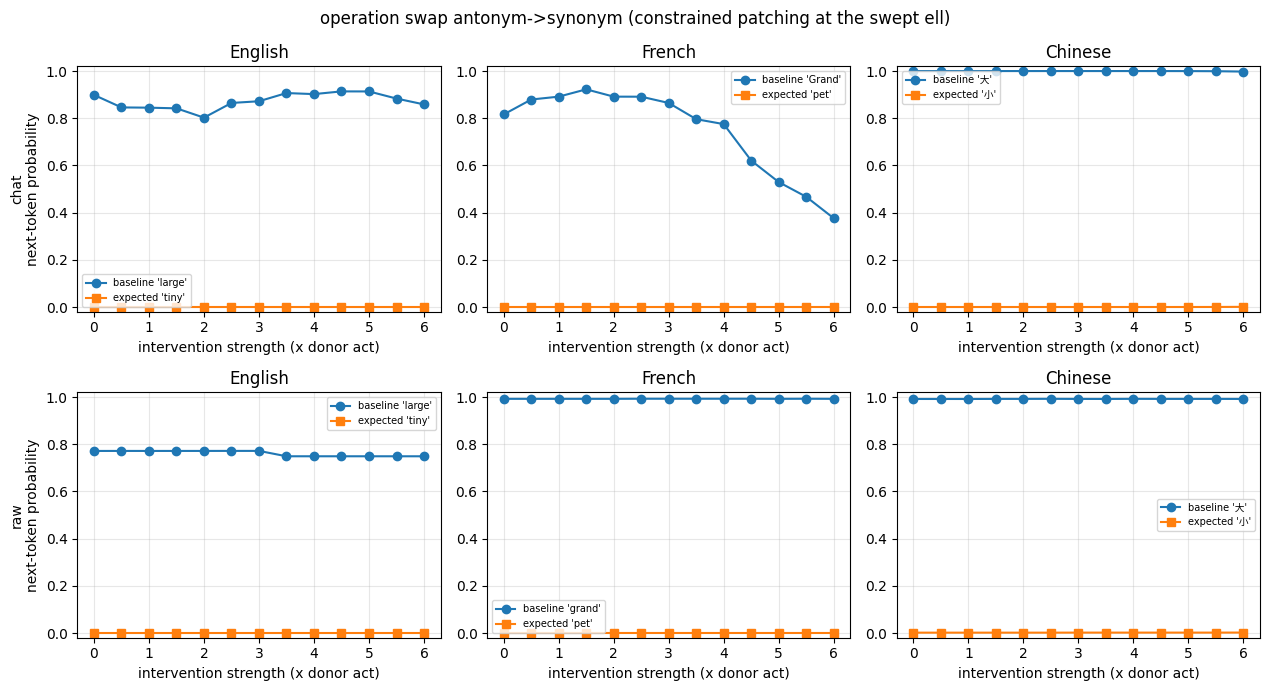

7078

In [6]:
kind = "operation"
_, don_max = M.PAPER_SWAP_STRENGTHS[kind]
op_results, op_readouts = {}, {}
for fmt in ("chat", "raw"):
    beh = behavior if fmt == "chat" else raw_behavior
    donor_graph = "synonym_en" if fmt == "chat" else "raw_synonym_en"
    for lg in M.LANGS:
        rec = f"antonym_{lg}" if fmt == "chat" else f"raw_antonym_{lg}"
        span = sorted(op_word_positions(graphs[rec], M.OP_WORD[lg]))
        assert span, f"operation word not found in {rec}"
        ivs_fn = M.swap_ivs_fn(
            SN[fmt]["antonym (multilingual)"],
            rec,
            fin[rec],
            SN[fmt]["synonym (multilingual)"],
            donor_graph,
            span,
            kind=kind,
        )
        expected = beh["synonym"][lg]["token_id"]
        ell, curve = M.choose_swap_end_layer(model, tc, ids[rec], ivs_fn(don_max), expected)
        r = M.supernode_swap_sweep(
            model,
            tc,
            ids[rec],
            ivs_fn,
            tokenizer,
            kind=kind,
            baseline_token=beh["antonym"][lg]["token_id"],
            expected_token=expected,
            patch_end_layer=ell,
        )
        r["l_max"] = curve.end_layers[0]
        r["ell_curve"] = {
            "end_layers": curve.end_layers,
            "p_expected": [round(p, 4) for p in curve.probs],
        }
        r["donor_span"] = {int(p): graphs[rec]["tokens"][p] for p in span}
        op_results[f"{fmt}_{lg}"] = r
        print(
            f"{fmt} {lg}: l_max={r['l_max']} ell={ell} | crossover={r['crossover']} "
            f"p_exp(max)={max(r['p_expected']):.3f} endpoint_top={r['top_tokens'][-1][:3]}"
        )
        # Fig B3 %-readouts at the endpoint (rows <= ell pinned by the protocol)
        ro = {
            "say_small_pct_stored": (SN[fmt]["say small (multilingual)"], donor_graph),
            "say_large_pct_baseline": (SN[fmt]["say large (multilingual)"], None),
            "opposite_lang_pct_baseline": (SN[fmt][f"opposite ({lg})"], None),
            "antonym_response_pct_baseline": (SN[fmt]["antonym (multilingual)"], None),
        }
        rl = M.readout_layers_above([sn for sn, _ in ro.values()], ell)
        res = M.run_feature_intervention(
            model,
            tc,
            ids[rec],
            ivs_fn(don_max),
            n_bos_tokens=M.N_BOS,
            patch_end_layer=ell,
            readout_layers=rl,
        )
        row = {
            name: M.supernode_readout(
                res, sn, rec, final_pos=fin[rec], ref_graph=rg, patch_end_layer=ell
            )
            for name, (sn, rg) in ro.items()
        }
        op_readouts[f"{fmt}_{lg}@{don_max:g}x"] = row
        M.print_readout_row(f"{fmt} {lg} @ {don_max:g}x [ell={ell}]", row)

fig, axes = plt.subplots(2, 3, figsize=(12.8, 7.0))
for ri, fmt in enumerate(("chat", "raw")):
    beh = behavior if fmt == "chat" else raw_behavior
    token_strs = {
        lg: (
            tokenizer.decode([beh["antonym"][lg]["token_id"]]).strip(),
            tokenizer.decode([beh["synonym"][lg]["token_id"]]).strip(),
        )
        for lg in M.LANGS
    }
    M.plot_swap_sweeps(
        {lg: op_results[f"{fmt}_{lg}"] for lg in M.LANGS},
        tokenizer,
        token_strs,
        title="",
        ax_row=axes[ri],
    )
    axes[ri][0].set_ylabel(f"{fmt}\nnext-token probability")
fig.suptitle("operation swap antonym->synonym (constrained patching at the swept ell)")
fig.tight_layout()
fig.savefig(OUT / "operation_sweep_constrained.png", dpi=130, bbox_inches="tight")
plt.show()
(OUT / "operation_results_constrained.json").write_text(
    json.dumps(op_results, indent=1, ensure_ascii=False, default=str)
)
(OUT / "operation_readouts_constrained.json").write_text(
    json.dumps(op_readouts, indent=1, ensure_ascii=False, default=str)
)

## D. Operand swap: small → hot (Fig B4; −0.5× source, +1.5× donor)

Per recipient (3 languages × chat/raw): the format's `small (multilingual)` steered to
−0.5× (m=−1.5) at each member's operand-token position (fallback: the manifest's
operand position); the format's `hot (multilingual)` injected at `value = +1.5× stored
act` on the format's donor graph at the recipient's operand token. Readout at the final
position. Paper: cold / f[roid] / 冷 — its cleanest intervention. Expected tokens are
the model's own hot-antonym answers per format (§0).

**Protocol note (per-format):** the chat sets are early (`small` L0–22, `hot` donors
L3–5), so `l_max = 22` and the say-cold / say-large readouts (L23+) sit above the floor
— measurable when the swept ℓ stays below them. The raw sets are late (`small` L26–28,
`hot` L24–27 ⇒ `l_max = 28`), so raw readouts are largely pinned.

chat en: l_max=22 ell=22 | crossover=None p_exp(max)=0.000 endpoint_top=[('large', 0.916), ('Large', 0.04), ('big', 0.04)]
readout chat en @ 1.5x [ell=22]: say_cold 13.1% (n=6), say_large 43.2% (n=6), opposite_lang None% (n=0, 6 pinned), small_response None% (n=0, 6 pinned)


chat fr: l_max=22 ell=30 | crossover=None p_exp(max)=0.000 endpoint_top=[('Grand', 0.816), ('grand', 0.182), ('Gr', 0.001)]
readout chat fr @ 1.5x [ell=30]: say_cold 0.0% (n=3, 3 pinned), say_large None% (n=0, 6 pinned), opposite_lang None% (n=0, 4 pinned), small_response None% (n=0, 6 pinned)


chat zh: l_max=22 ell=23 | crossover=None p_exp(max)=0.000 endpoint_top=[('大', 1.0), ('"', 0.0), ('大的', 0.0)]
readout chat zh @ 1.5x [ell=23]: say_cold 3.0% (n=6), say_large 63.2% (n=5, 1 pinned), opposite_lang None% (n=0, 6 pinned), small_response None% (n=0, 6 pinned)


raw en: l_max=28 ell=28 | crossover=None p_exp(max)=0.000 endpoint_top=[('large', 0.696), ('big', 0.29), ('huge', 0.004)]
readout raw en @ 1.5x [ell=28]: say_cold 1.7% (n=4, 1 pinned), say_large 80.2% (n=6), opposite_lang None% (n=0, 6 pinned), small_response None% (n=0, 6 pinned)


raw fr: l_max=28 ell=28 | crossover=None p_exp(max)=0.000 endpoint_top=[('grand', 0.988), ('gr', 0.007), ('g', 0.004)]
readout raw fr @ 1.5x [ell=28]: say_cold 3.7% (n=4, 1 pinned), say_large 78.6% (n=6), opposite_lang None% (n=0, 6 pinned), small_response None% (n=0, 6 pinned)


raw zh: l_max=28 ell=35 | crossover=None p_exp(max)=0.000 endpoint_top=[('大', 0.99), ('____', 0.002), ('小', 0.001)]
readout raw zh @ 1.5x [ell=35]: say_cold None% (n=0, 5 pinned), say_large None% (n=0, 6 pinned), opposite_lang None% (n=0, 6 pinned), small_response None% (n=0, 6 pinned)


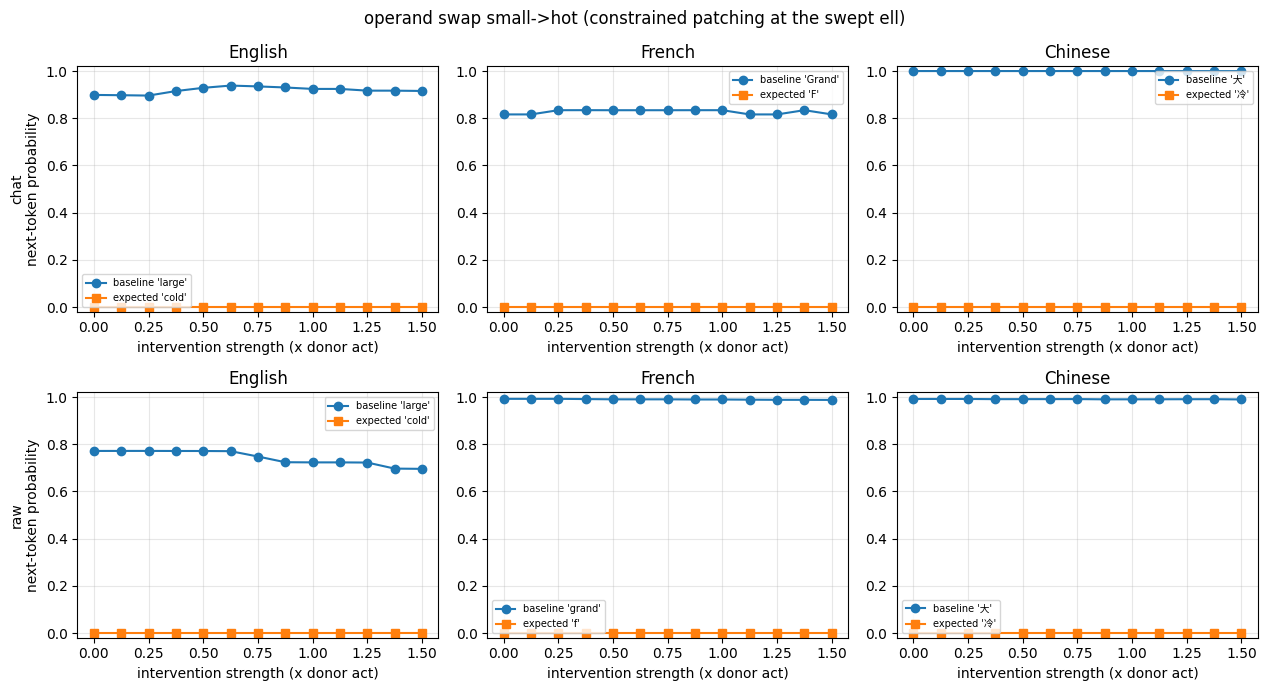

7406

In [7]:
kind = "operand"
_, don_max = M.PAPER_SWAP_STRENGTHS[kind]
od_results, od_readouts = {}, {}
for fmt in ("chat", "raw"):
    beh = behavior if fmt == "chat" else raw_behavior
    donor_graph = "hot_en" if fmt == "chat" else "raw_hot_en"
    for lg in M.LANGS:
        rec = f"antonym_{lg}" if fmt == "chat" else f"raw_antonym_{lg}"
        opos = manifest["graphs"][rec]["operand_position"]
        ivs_fn = M.swap_ivs_fn(
            SN[fmt]["small (multilingual)"],
            rec,
            opos,
            SN[fmt]["hot (multilingual)"],
            donor_graph,
            [opos],
            kind=kind,
        )
        expected = beh["antonym_hot"][lg]["token_id"]
        ell, curve = M.choose_swap_end_layer(model, tc, ids[rec], ivs_fn(don_max), expected)
        r = M.supernode_swap_sweep(
            model,
            tc,
            ids[rec],
            ivs_fn,
            tokenizer,
            kind=kind,
            baseline_token=beh["antonym"][lg]["token_id"],
            expected_token=expected,
            patch_end_layer=ell,
        )
        r["l_max"] = curve.end_layers[0]
        r["ell_curve"] = {
            "end_layers": curve.end_layers,
            "p_expected": [round(p, 4) for p in curve.probs],
        }
        r["operand_position"] = {int(opos): graphs[rec]["tokens"][opos]}
        od_results[f"{fmt}_{lg}"] = r
        print(
            f"{fmt} {lg}: l_max={r['l_max']} ell={ell} | crossover={r['crossover']} "
            f"p_exp(max)={max(r['p_expected']):.3f} endpoint_top={r['top_tokens'][-1][:3]}"
        )
        ro = {
            "say_cold_pct_stored": (SN[fmt]["say cold (multilingual)"], donor_graph),
            "say_large_pct_baseline": (SN[fmt]["say large (multilingual)"], None),
            "opposite_lang_pct_baseline": (SN[fmt][f"opposite ({lg})"], None),
            "small_response_pct_baseline": (SN[fmt]["small (multilingual)"], None),
        }
        rl = M.readout_layers_above([sn for sn, _ in ro.values()], ell)
        res = M.run_feature_intervention(
            model,
            tc,
            ids[rec],
            ivs_fn(don_max),
            n_bos_tokens=M.N_BOS,
            patch_end_layer=ell,
            readout_layers=rl,
        )
        row = {
            name: M.supernode_readout(
                res, sn, rec, final_pos=fin[rec], ref_graph=rg, patch_end_layer=ell
            )
            for name, (sn, rg) in ro.items()
        }
        od_readouts[f"{fmt}_{lg}@{don_max:g}x"] = row
        M.print_readout_row(f"{fmt} {lg} @ {don_max:g}x [ell={ell}]", row)

fig, axes = plt.subplots(2, 3, figsize=(12.8, 7.0))
for ri, fmt in enumerate(("chat", "raw")):
    beh = behavior if fmt == "chat" else raw_behavior
    token_strs = {
        lg: (
            tokenizer.decode([beh["antonym"][lg]["token_id"]]).strip(),
            tokenizer.decode([beh["antonym_hot"][lg]["token_id"]]).strip(),
        )
        for lg in M.LANGS
    }
    M.plot_swap_sweeps(
        {lg: od_results[f"{fmt}_{lg}"] for lg in M.LANGS},
        tokenizer,
        token_strs,
        title="",
        ax_row=axes[ri],
    )
    axes[ri][0].set_ylabel(f"{fmt}\nnext-token probability")
fig.suptitle("operand swap small->hot (constrained patching at the swept ell)")
fig.tight_layout()
fig.savefig(OUT / "operand_sweep_constrained.png", dpi=130, bbox_inches="tight")
plt.show()
(OUT / "operand_results_constrained.json").write_text(
    json.dumps(od_results, indent=1, ensure_ascii=False, default=str)
)
(OUT / "operand_readouts_constrained.json").write_text(
    json.dumps(od_readouts, indent=1, ensure_ascii=False, default=str)
)

## E. Language swap: X → Y (Fig B5; −5× source, +6× donor) — raw pages only

Paper protocol: swap the language-tracking features on the final token — `quote (X)`
steered to −5× (m=−6), `quote (Y)` injected at `value = +6× its stored act` at the
recipient's final open-quote position — EN→ZH, FR→EN, ZH→FR; the output language should
change while operation and operand are preserved (say-large-multilingual ≈100%, old
say-large-X 18–39%, new say-large-Y 76–105% in the paper's annotations). **Raw-only by
construction:** the quote supernodes exist only on the raw pages. Qwen3 caveat measured
at selection time: the quote features sit at L23–L34, not the paper's early layers —
Qwen3's raw graphs keep no early quote-position nodes at all, so the sweep floor
`l_max` is high (32–34) in every direction.

Readout caveats from the separated raw selection: there is **no `say large (zh)`**
(zero raw candidates), so the en→zh target-language readout row does not exist, and
`say large (en)` has a single member — rows are skipped with a printed note where a
group is absent.

en->zh: l_max=34 ell=35 p_exp max over ell 0.6367 | crossover=5.5 endpoint_top=[('大', 0.636), ('large', 0.125), ('（', 0.097)]
   ('say large (zh)' absent from the raw selection — row skipped)
readout en->zh @ 6x [ell=35]: say_large_multi None% (n=0, 6 pinned), say_large_src None% (n=0, 1 pinned), quote_src_response None% (n=0, 6 pinned), quote_tgt_response None% (n=0, 6 pinned)


fr->en: l_max=32 ell=32 p_exp max over ell 0.0121 | crossover=6.0 endpoint_top=[('big', 0.753), ('great', 0.19), ('大', 0.016)]
readout fr->en @ 6x [ell=32]: say_large_multi None% (n=0, 6 pinned), say_large_src 0.0% (n=1, 5 pinned), say_large_tgt None% (n=0, 1 pinned), quote_src_response None% (n=0, 6 pinned), quote_tgt_response None% (n=0, 6 pinned)


zh->fr: l_max=34 ell=34 p_exp max over ell 0.0003 -- p_exp ~0 at EVERY ell (no landing layer exists) | crossover=None endpoint_top=[('à', 0.066), ('grand', 0.062), ('é', 0.051)]
   ('say large (zh)' absent from the raw selection — row skipped)
readout zh->fr @ 6x [ell=34]: say_large_multi None% (n=0, 6 pinned), say_large_tgt None% (n=0, 6 pinned), quote_src_response None% (n=0, 6 pinned), quote_tgt_response None% (n=0, 6 pinned)


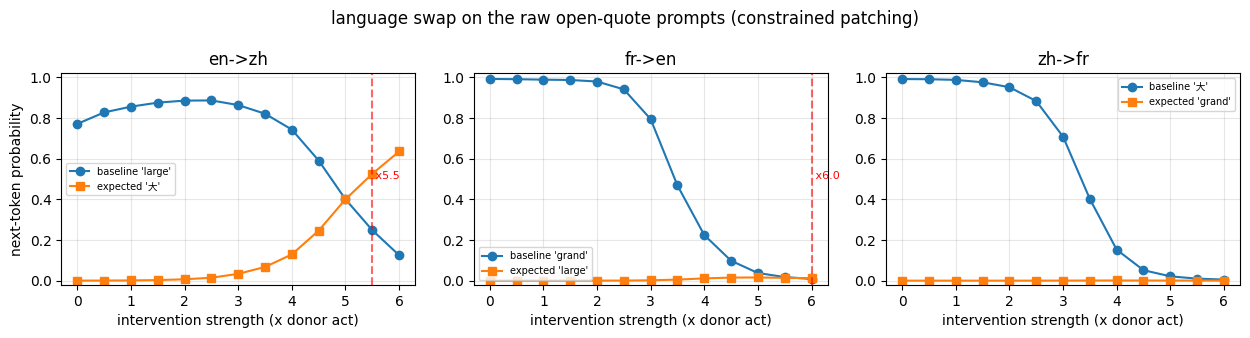

3946

In [8]:
kind = "language"
_, don_max = M.PAPER_SWAP_STRENGTHS[kind]
SNR = SN["raw"]
DIRECTIONS = [("en", "zh"), ("fr", "en"), ("zh", "fr")]
lang_results, lang_readouts, lang_ivs_fns, lang_ells = {}, {}, {}, {}
for src_lg, tgt_lg in DIRECTIONS:
    key = f"{src_lg}->{tgt_lg}"
    rec = f"raw_antonym_{src_lg}"
    donor_graph = f"raw_antonym_{tgt_lg}"
    ivs_fn = M.swap_ivs_fn(
        SNR[f"quote ({src_lg})"],
        rec,
        fin[rec],
        SNR[f"quote ({tgt_lg})"],
        donor_graph,
        [fin[rec]],
        kind=kind,
    )
    lang_ivs_fns[key] = ivs_fn
    expected = raw_behavior["antonym"][tgt_lg]["token_id"]
    ell, curve = M.choose_swap_end_layer(model, tc, ids[rec], ivs_fn(don_max), expected)
    lang_ells[key] = ell
    vac = " -- p_exp ~0 at EVERY ell (no landing layer exists)" if max(curve.probs) < 1e-3 else ""
    r = M.supernode_swap_sweep(
        model,
        tc,
        ids[rec],
        ivs_fn,
        tokenizer,
        kind=kind,
        baseline_token=raw_behavior["antonym"][src_lg]["token_id"],
        expected_token=expected,
        patch_end_layer=ell,
    )
    r["l_max"] = curve.end_layers[0]
    r["ell_curve"] = {
        "end_layers": curve.end_layers,
        "p_expected": [round(p, 6) for p in curve.probs],
    }
    lang_results[key] = r
    print(
        f"{key}: l_max={r['l_max']} ell={ell} p_exp max over ell {max(curve.probs):.4f}{vac} | "
        f"crossover={r['crossover']} endpoint_top={r['top_tokens'][-1][:3]}"
    )
    ro = {}
    for label, sn_name, rg in [
        ("say_large_multi_pct_baseline", "say large (multilingual)", None),
        ("say_large_src_pct_baseline", f"say large ({src_lg})", None),
        ("say_large_tgt_pct_stored", f"say large ({tgt_lg})", donor_graph),
        ("quote_src_response_pct_baseline", f"quote ({src_lg})", None),
        ("quote_tgt_response_pct_stored", f"quote ({tgt_lg})", donor_graph),
    ]:
        if sn_name in SNR:
            ro[label] = (SNR[sn_name], rg)
        else:
            print(f"   ({sn_name!r} absent from the raw selection — row skipped)")
    rl = M.readout_layers_above([sn for sn, _ in ro.values()], ell)
    res = M.run_feature_intervention(
        model,
        tc,
        ids[rec],
        ivs_fn(don_max),
        n_bos_tokens=M.N_BOS,
        patch_end_layer=ell,
        readout_layers=rl,
    )
    row = {
        name: M.supernode_readout(
            res, sn, rec, final_pos=fin[rec], ref_graph=rg, patch_end_layer=ell
        )
        for name, (sn, rg) in ro.items()
    }
    lang_readouts[f"{key}@{don_max:g}x"] = row
    M.print_readout_row(f"{key} @ {don_max:g}x [ell={ell}]", row)

token_strs = {
    f"{a}->{b}": (
        tokenizer.decode([raw_behavior["antonym"][a]["token_id"]]).strip(),
        tokenizer.decode([raw_behavior["antonym"][b]["token_id"]]).strip(),
    )
    for a, b in DIRECTIONS
}
ax_row = M.plot_swap_sweeps(lang_results, tokenizer, token_strs, title="")
plt.suptitle("language swap on the raw open-quote prompts (constrained patching)")
plt.tight_layout()
plt.savefig(OUT / "language_sweep_constrained.png", dpi=130, bbox_inches="tight")
plt.show()
(OUT / "language_results_constrained.json").write_text(
    json.dumps(lang_results, indent=1, ensure_ascii=False, default=str)
)
(OUT / "language_readouts_constrained.json").write_text(
    json.dumps(lang_readouts, indent=1, ensure_ascii=False, default=str)
)

In [9]:
# Fig B5-style per-feature ladder for raw en->zh at 1x/3x/6x (the F8 recheck): does the
# target language's say-stage EVER come online while the en quote supernode is driven at
# paper strengths? Constrained at the direction's chosen ell. The separated raw
# selection has NO say large (zh) group (zero candidates on the raw zh page), so the
# target-language row cannot exist here — the multilingual say-large group and the
# (single-member) say large (en) carry whatever is readable above ell.
ivs_fn = lang_ivs_fns["en->zh"]
ell = lang_ells["en->zh"]
rec = "raw_antonym_en"
groups = {}
for label, sn_name, rg in [
    ("say_large_multi", "say large (multilingual)", None),
    ("say_large_en", "say large (en)", None),
    ("say_large_zh", "say large (zh)", "raw_antonym_zh"),
]:
    if sn_name in SNR:
        groups[label] = (SNR[sn_name], rg)
    else:
        print(f"({sn_name!r} absent from the raw selection — ladder row skipped)")
rl = M.readout_layers_above([sn for sn, _ in groups.values()], ell)
ladder = {}
for s in (1.0, 3.0, 6.0):
    res = M.run_feature_intervention(
        model,
        tc,
        ids[rec],
        ivs_fn(s),
        n_bos_tokens=M.N_BOS,
        patch_end_layer=ell,
        readout_layers=rl,
    )
    row = {
        name: M.supernode_readout(
            res, sn, rec, final_pos=fin[rec], ref_graph=rg, patch_end_layer=ell
        )
        for name, (sn, rg) in groups.items()
    }
    print(
        f"raw en->zh @ {s:g}x [ell={ell}]: "
        f"top {M.top_token_probs(res.ablated_logits[-1], tokenizer, k=3)}"
    )
    M.print_readout_row(f"  en->zh @ {s:g}x", row)
    ladder[f"{s:g}x"] = row
(OUT / "language_ladder_readouts_constrained.json").write_text(
    json.dumps(ladder, indent=1, ensure_ascii=False, default=str)
)

('say large (zh)' absent from the raw selection — ladder row skipped)
raw en->zh @ 1x [ell=35]: top [('large', 0.856), ('big', 0.131), ('____', 0.004)]
readout   en->zh @ 1x: say_large_multi None% (n=0, 6 pinned), say_large_en None% (n=0, 1 pinned)


raw en->zh @ 3x [ell=35]: top [('large', 0.864), ('big', 0.049), ('大', 0.033)]
readout   en->zh @ 3x: say_large_multi None% (n=0, 6 pinned), say_large_en None% (n=0, 1 pinned)
raw en->zh @ 6x [ell=35]: top [('大', 0.636), ('large', 0.125), ('（', 0.097)]
readout   en->zh @ 6x: say_large_multi None% (n=0, 6 pinned), say_large_en None% (n=0, 1 pinned)


1418

## F. Cross-lingual feature overlap by layer (Fig B7)

The paper's IOU protocol: per layer, the intersection-over-union of the feature sets
**active anywhere in the context**, on translated paragraphs, against an **unrelated-pair
baseline** (paragraph i in language A vs paragraph i+1 in language B). Paper shape: low at
both ends, mid-network peak well above baseline; EN-FR (shared alphabet) highest.

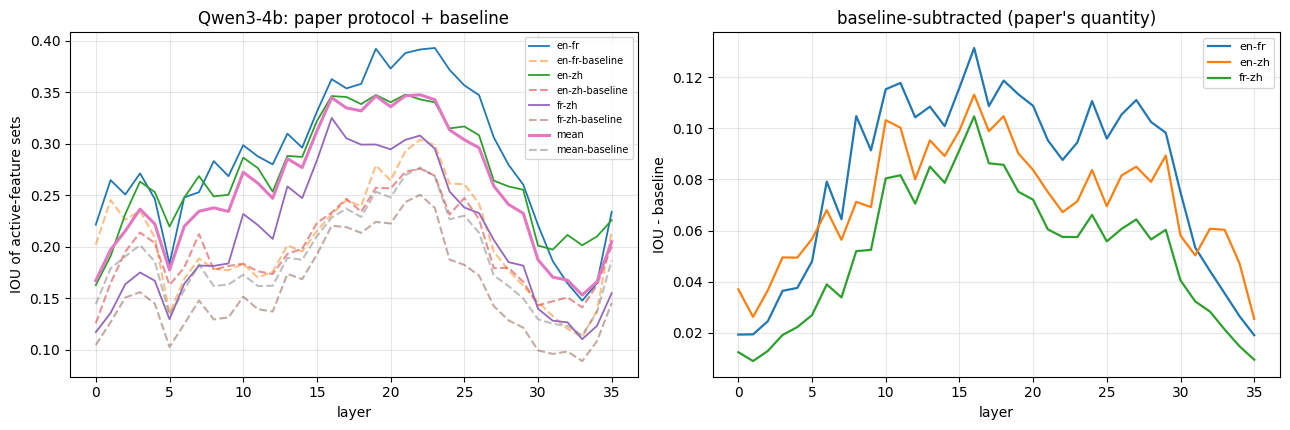

en-fr: raw peak 0.393@L23, baseline-subtracted mid-third mean 0.107, ends 0.019/0.019
en-zh: raw peak 0.348@L21, baseline-subtracted mid-third mean 0.089, ends 0.037/0.025
fr-zh: raw peak 0.325@L16, baseline-subtracted mid-third mean 0.077, ends 0.012/0.010
mean active-set size/layer: min 348, median 935, max 1570 (dict 163840)


In [10]:
corpus = M.CORPUS + M.PARAGRAPHS
curves = M.overlap_curves_paper(model, tc, tokenizer, corpus)
(OUT / "overlap_curves.json").write_text(
    json.dumps({k: v.tolist() for k, v in curves.items()}, indent=1)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for key, arr in curves.items():
    if key == "set-size":
        continue
    if key.endswith("baseline"):
        axes[0].plot(arr, "--", alpha=0.5, label=key)
    else:
        axes[0].plot(arr, lw=2.2 if key == "mean" else 1.3, label=key)
axes[0].set_xlabel("layer")
axes[0].set_ylabel("IOU of active-feature sets")
axes[0].set_title(f"Qwen3-{SIZE}: paper protocol + baseline")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)
for pair in ("en-fr", "en-zh", "fr-zh"):
    axes[1].plot(curves[pair] - curves[f"{pair}-baseline"], lw=1.6, label=pair)
axes[1].set_xlabel("layer")
axes[1].set_ylabel("IOU - baseline")
axes[1].set_title("baseline-subtracted (paper's quantity)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "overlap_paper.png", dpi=130)
plt.show()

lo, hi = N_LAYERS // 3, 2 * N_LAYERS // 3
for pair in ("en-fr", "en-zh", "fr-zh"):
    exc = curves[pair] - curves[f"{pair}-baseline"]
    print(
        f"{pair}: raw peak {curves[pair].max():.3f}@L{int(curves[pair].argmax())}, "
        f"baseline-subtracted mid-third mean {exc[lo:hi].mean():.3f}, ends {exc[0]:.3f}/{exc[-1]:.3f}"
    )
ss = curves["set-size"]
print(
    f"mean active-set size/layer: min {ss.min():.0f}, median {np.median(ss):.0f}, "
    f"max {ss.max():.0f} (dict 163840)"
)

## G. Which language is the mechanistic default?

Paper (§B.3.4, Claude-specific): multilingual say-large features push the **English**
token hardest — "English is mechanistically privileged as the default". The transferable
claim is that *some* language plays that role. We take the shared say-big features (late
layers, in ≥2 of the three antonym graphs among the influence-top answer features) and
compare each one's **direct decoder effect** on the EN/FR/ZH answer-token logits.

In [11]:
tok_ids = {lg: behavior["antonym"][lg]["token_id"] for lg in M.LANGS}
member = {}
for lg in M.LANGS:
    for n in M.answer_features(graphs[f"antonym_{lg}"], top_k=12):
        member.setdefault((n["layer"], n["feature_idx"]), []).append(lg)
shared = {k: v for k, v in member.items() if len(v) >= 2 and k[0] >= N_LAYERS // 2}
effects = {}
for (L, f), langs_with in sorted(shared.items()):
    eff = M.direct_logit_effect(model, tc, L, f, tok_ids)
    effects[f"L{L}f{f}"] = eff
    print(
        f"L{L}f{f} (in {'/'.join(langs_with)}): "
        + ", ".join(f"{lg}={eff[lg]:+.3f}" for lg in M.LANGS)
    )
if effects:
    means = {lg: float(np.mean([e[lg] for e in effects.values()])) for lg in M.LANGS}
    print(
        f"\nmean direct effect over {len(effects)} shared say-big features: "
        + ", ".join(f"{lg}={means[lg]:.3f}" for lg in sorted(means, key=means.get, reverse=True))
    )

L30f27666 (in en/fr/zh): en=+0.701, fr=+0.326, zh=+0.636
L30f57180 (in en/zh): en=+0.480, fr=+0.023, zh=+0.316
L31f11436 (in en/zh): en=+0.699, fr=+0.218, zh=+1.128
L32f100307 (in fr/zh): en=+0.775, fr=+0.669, zh=+0.983

mean direct effect over 4 shared say-big features: zh=0.766, en=0.664, fr=0.309


/teamspace/studios/this_studio/llm-circuits/notebooks/multilingual_helper.py:528: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return {lg: float(demeaned[t]) for lg, t in token_ids.items()}


In [12]:
# Explorer HTMLs with each format's supernodes pre-loaded as GROUPS (the review-page
# convention; "Export groups" round-trips them for any future re-selection).
from llm_circuits.circuits.graph_explorer import render_graph_explorer_html

for name in GRAPH_NAMES:
    fmt = "raw" if manifest["graphs"][name]["raw"] else "chat"
    gspecs = []
    for sn_name, sn in SN[fmt].items():
        members = [
            (m["layer"], m["feature"]) for m in sn["members"] if name in (m.get("positions") or {})
        ]
        if members:
            gspecs.append({"name": sn_name, "members": members, "position": None})
    render_graph_explorer_html(graphs[name], OUT / f"graph_{name}.html", title=name, groups=gspecs)
    print(f"graph_{name}.html: {len(gspecs)} groups ({fmt} selection)")

graph_antonym_en.html: 5 groups (chat selection)


graph_antonym_fr.html: 5 groups (chat selection)


graph_antonym_zh.html: 5 groups (chat selection)


graph_synonym_en.html: 2 groups (chat selection)


graph_hot_en.html: 2 groups (chat selection)
graph_raw_antonym_en.html: 6 groups (raw selection)


graph_raw_antonym_fr.html: 6 groups (raw selection)


graph_raw_antonym_zh.html: 5 groups (raw selection)


graph_raw_synonym_en.html: 2 groups (raw selection)


graph_raw_hot_en.html: 2 groups (raw selection)


## H. Scale comparison: 4b vs 8b overlap (Fig B7's model comparison)

Paper: Haiku shares markedly more than its smaller 18L counterpart, most of all on the
non-alphabet-sharing pairs (EN-ZH, FR-ZH). This run uses the registry's **same-recipe
pair**: `mwhanna/qwen3-4b-transcoders` vs `mwhanna/qwen3-8b-transcoders` (both plain
recipe, both 36 layers, both 163,840 features/layer), with per-layer active-set sizes
printed as the granularity check (IOU is mechanically sensitive to how many features
fire). We free the 4b and run the identical overlap protocol on Qwen3-8B — overlap is
encode-only, so lazy decoders keep the 8B well inside an A100-80GB.

[07/12/26 02:30:15] INFO     Loading model Qwen/Qwen3-8B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/models)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

[07/12/26 02:30:22] INFO     Loading transcoders from cache mwhanna/qwen3-8b-transcoders                           
                             (cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/transcoders)

4b: mean active-set size/layer min 348 / median 935 / max 1570 (dict 163840)
8b: mean active-set size/layer min 583 / median 1206 / max 4099 (dict 163840)


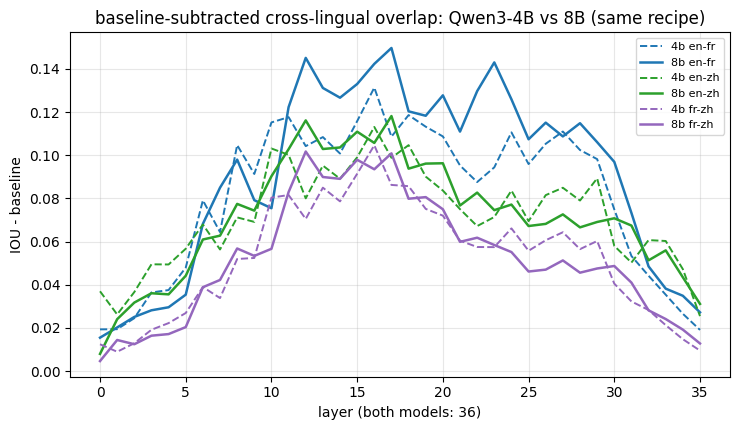

en-fr: baseline-subtracted mid-third mean  4b=0.107  8b=0.132
en-zh: baseline-subtracted mid-third mean  4b=0.089  8b=0.098
fr-zh: baseline-subtracted mid-third mean  4b=0.077  8b=0.082


In [13]:
del model, tc
gc.collect()
torch.cuda.empty_cache()

model8, tokenizer8 = load_qwen3("8b", dtype_str="bf16", device_map=DEVICE)
model8.eval()
tc8 = load_transcoder("qwen3-8b", device=DEVICE, dtype=torch.bfloat16).transcoder
curves8 = M.overlap_curves_paper(model8, tc8, tokenizer8, corpus)
OUT8 = artifacts_dir() / "paper_multilingual" / "8b"
OUT8.mkdir(parents=True, exist_ok=True)
(OUT8 / "overlap_curves.json").write_text(
    json.dumps({k: v.tolist() for k, v in curves8.items()}, indent=1)
)

# same-recipe granularity check (IOU is mechanically sensitive to active-set size)
for name, c in (("4b", curves), ("8b", curves8)):
    ss = c["set-size"]
    print(
        f"{name}: mean active-set size/layer min {ss.min():.0f} / median {np.median(ss):.0f} / "
        f"max {ss.max():.0f} (dict 163840)"
    )

fig, ax = plt.subplots(figsize=(7.5, 4.4))
for pair, color in (("en-fr", "C0"), ("en-zh", "C2"), ("fr-zh", "C4")):
    ax.plot(
        curves[pair] - curves[f"{pair}-baseline"], color=color, lw=1.4, ls="--", label=f"4b {pair}"
    )
    ax.plot(curves8[pair] - curves8[f"{pair}-baseline"], color=color, lw=1.8, label=f"8b {pair}")
ax.set_xlabel("layer (both models: 36)")
ax.set_ylabel("IOU - baseline")
ax.set_title("baseline-subtracted cross-lingual overlap: Qwen3-4B vs 8B (same recipe)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT8 / "overlap_scale_comparison.png", dpi=130)
plt.show()


def midmean(c, n, pair):
    exc = c[pair] - c[f"{pair}-baseline"]
    return float(exc[n // 3 : 2 * n // 3].mean())


for pair in ("en-fr", "en-zh", "fr-zh"):
    print(
        f"{pair}: baseline-subtracted mid-third mean  4b={midmean(curves, N_LAYERS, pair):.3f}  "
        f"8b={midmean(curves8, len(tc8), pair):.3f}"
    )

## Summary — verdicts vs the paper

Constrained patching throughout (ℓ swept per job on p(expected), stated per row);
chat and raw are **separate selections**, both earliest-layer-first and seed-approved
(user decisions 2026-07-12). v1 (propagate) and v2 (merged act-ranked selection,
hand-reviewed) live in git history and `DEVLOG.md`.

| Paper experiment (Claude 3.5 Haiku) | This run (Qwen3-4B, per-format selections, constrained-only) | Verdict |
|---|---|---|
| Behavior: big / grand / 大 (raw prompts) | raw large / grand / 大 ✓, chat large / Grand / 大 ✓; hot-antonym cold / f(roid) / 冷 ✓; synonym EN `tiny` ✓ but FR **echoes the operand** (pet) and ZH echoes 小 — swap targets are the model's own answers | **reproduced** (antonym); synonym degenerate FR/ZH |
| Shared multilingual core (20/27 supernode features active on all three prompts; 10/27 in all pruned graphs) | pruned-graph intersections: **107** features in all three chat graphs (of 437–621 per graph), **67** in all three raw (of 239–439). Per-format supernode presence on all three antonym pages: chat antonym 3/6, say large 5/6, but the earliest-first chat `small` **0/6** (its early members are two-page features); raw antonym 1/1, small 4/6, say large 4/6 | **reproduced** (structure; the early chat operand features are the least cross-lingual) |
| Operation swap −5×/+6×: synonyms top-1, crossover ≈4×, upstream ≈100%, say-large suppressed | **not reproduced in either regime — and the two regimes now fail for complementary, measured reasons.** *Raw* (antonym = single L34 member, donors ≤L34): ℓ ∈ {34, 35}, direct-effect-only, p(expected) ≤ 0.002, baseline top-1 at the endpoint (grand @ .992, 大 @ .992), all readouts pinned. *Chat* (antonym L7–13, donors L4–9 ⇒ l_max=13): the sweep has full room ([13, 35], ℓ chosen 14–16) and the Fig B3 annotations are **readable for the first time** — and they show the mechanism moving in the paper's direction but far too weakly: `say small` recruits to only **13–35%** of its donor-graph level (paper: flips the output), `say large` falls to 91/77/34% (paper: ~0–20%), while p(expected synonym) stays ≤ 0.001 and the antonym answer keeps top-1 (large @ .859, 大 @ .998). At paper strengths, the early members' small activations (3–10) produce deltas that move the say-stage a third of the way at best | **not reproduced** (raw: no protocol room; chat: room but ~3–7× too little effect — an effect-size gap, now measured via the readable readouts) |
| Operand swap −0.5×/+1.5× → cold / f[roid] / 冷 (paper's cleanest) | same two-regime structure: no flip anywhere (p(expected) = 0.000 in all six jobs, baseline top-1: chat 大 @ 1.0, raw grand @ .988). *Chat* (small L0–22 incl. the L0/L19 early shared features, hot donors L3–5 ⇒ l_max=22): readouts readable — `say cold` recruits to only **1.7–13%** of donor level, `say large` drops to 43–80%. *Raw* (l_max=28): say-cold 1.7–3.7%, say-large ≈80% where readable | **not reproduced** (both regimes; the recruitment the paper relies on reaches ≤13% here) |
| Language swap −5×/+6× (EN→ZH → 大, FR→EN → big, ZH→FR → grand); say-large-multilingual ≈100%, old 18–39%, new 76–105% | **works in 2/3 directions** (quote groups identical to v2, results reproduce exactly): en→zh **大 top-1 @ 0.636** (ℓ=35, crossover 5.5×); fr→en turns English — **big @ 0.753** + great @ 0.19, the paper's exact FR→EN token (p_expected tracked the model's own raw-EN answer `large`, under-reporting the flip); zh→fr no flip (p_exp ≈ 0 at every ℓ). Readout cost of the separation: `say large (zh)` has no raw group (row absent) and the raw `say large (en)` single member sits at L32 = ℓ (pinned) — v2's cross-format 121.6% recruitment reading is no longer measurable; the surviving readable row, fr→en `say large (fr)` = **0.0%**, still matches the paper's old-language suppression | **partially reproduced** (2/3 directions, paper's exact outcome tokens; the causal handle is late — L23–34 quote features — not the paper's early detection stage) |
| Overlap by layer (Fig B7): mid-network peak ≫ baseline, ends low; EN-FR highest | baseline-subtracted mid-third: en-fr **0.107** > en-zh 0.089 > fr-zh 0.077; inverted-U with low ends (protocol-independent; unchanged across v1–v3) | **reproduced** |
| English as the mechanistic default (Claude-specific) | mean direct decoder effect of the 4 shared say-big features on the answer logits: **zh 0.766 > en 0.664 ≫ fr 0.309** | **model difference** — the transferable claim (*some* default) holds; on EN/ZH-trained Qwen3 the role is shared EN/ZH, Chinese slightly ahead |
| Scale: Haiku ≫ 18L, biggest gain on non-alphabet pairs | same-recipe pair (4b vs 8b, both 36L, 163,840 feats/layer): **8b > 4b on every pair** — 0.132/0.098/0.082 vs 0.107/0.089/0.077 mid-third; gain concentrates on en-fr (+23%) rather than the paper's emphasized non-alphabet pairs (en-zh +10%, fr-zh +6%); active-set medians 935 vs 1206 | **reproduced** (direction, on a clean pair; which pairs gain most differs) |

**Bottom line.** With the selection policy (earliest-layer-first) and the chat/raw
separation both fixed by design, the three swaps dissociate even more sharply than in
v2. The **language swap** remains the one paper-style success: the late (L23–34) quote
features flip the output language in two of three directions with the paper's exact
tokens, essentially as a direct effect (ℓ=35). The **operation and operand swaps fail
in both regimes, for complementary measured reasons**: the raw selections are so late
(single-L34 antonym) that the protocol leaves no recompute room, while the chat
selections are early enough to give the protocol full room ([13, 35] / [22, 35]) and
readable Fig B3/B4 annotations — which then show the intervention moving the say-stage
only 2–35% of the way at the paper's strengths. Haiku's mid-network supernodes
evidently supplied room *and* strength at once; Qwen3-4B's defensible selections offer
one or the other, never both. Overlap, the EN/ZH-shared default, and the 4b→8b scale
trend are selection-independent and reproduce throughout.

**Protocol postscript.** Measured ℓ floors: operation l_max = 13 (chat) / 34 (raw),
operand 22 / 28, language 32–34. The Fig B3/B4 node annotations are measurable on the
chat side for the first time (n_used = 6 rows vs all-pinned in v2); Fig B5's readable
rows still match the paper's old-language suppression, while the new-language
recruitment reading was lost to the raw selection's own geometry (single L32 member at
ℓ). What "the paper's protocol needs" is now characterized on this model from both
sides: room without strength (chat) and strength without room (raw).

Full cross-referenced verdicts in `DEVLOG.md`; paper values in `notes/biology_digest.md` §B.